In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X= 6*np.random.rand(200,1)-3
y= 0.8*X**2 +0.9*X+2+np.random.randn(200,1)
# y= 0.8x^2 + 0.9x +2 + noise to make data more realistic

Text(0, 0.5, 'y')

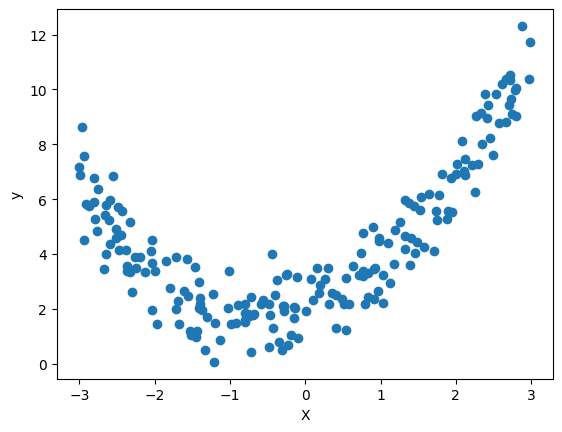

In [4]:
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")

# Train test split

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# Applying Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(X_train, y_train)
y_pred= lr.predict(X_test)

In [7]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.39078162781819537

##### By applying linear regression only in these type of data makes the model inaccurate

Text(0, 0.5, 'y')

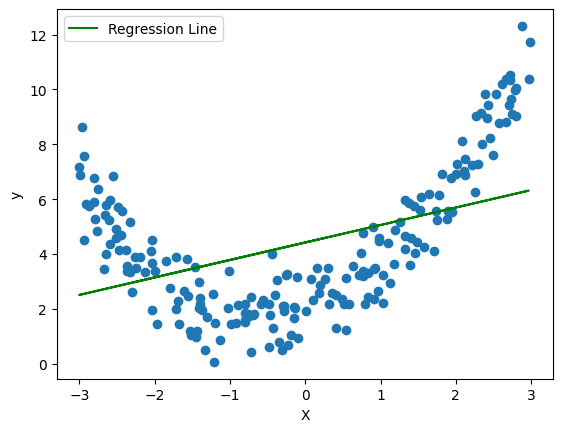

In [8]:
plt.scatter(X, y)
plt.plot(X_train, lr.predict(X_train), color="green", label="Regression Line") 
# We trained the model using training data, so the regression line is based on training data.
plt.legend()
plt.xlabel("X")
plt.ylabel("y")

# Applying Polynomial Rgression

In [9]:
from sklearn.preprocessing import PolynomialFeatures
poly= PolynomialFeatures(degree=2, include_bias=True)  # False will not give x^0 column
X_train_transformed= poly.fit_transform(X_train)
X_test_transformed= poly.transform(X_test)


In [10]:
print(X_train[0])
print(X_train_transformed[0]) # X^0 X^1 X^2

[-2.25758082]
[ 1.         -2.25758082  5.09667116]


In [11]:
lr.fit(X_train_transformed, y_train)
y_pred= lr.predict(X_test_transformed)


In [12]:
r2_score(y_test, y_pred)

0.9019906082295813

##### We can see that by applying Polynomial Regression the model is much better

In [13]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.86194518 0.78182604]]
[1.94909178]


In [31]:
X_curve = np.linspace(-3, 3, 200).reshape(-1,1) 
X_curve_poly= poly.transform(X_curve)
y_curve= lr.predict(X_curve_poly)

# We used new X values just to DRAW a smooth curve of the model that was trained on old data.

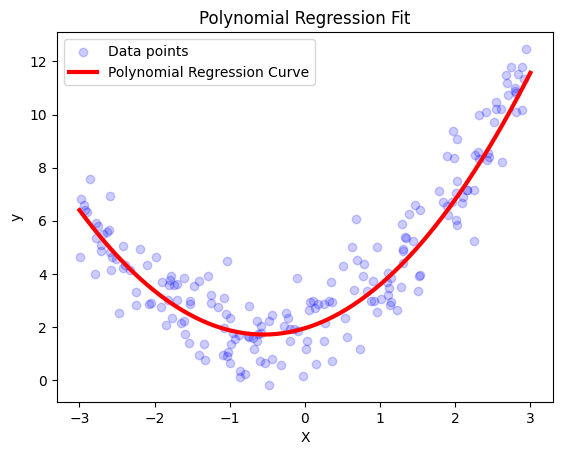

In [32]:
plt.scatter(X, y, color='blue', alpha=0.2, label="Data points")
plt.plot(X_curve, y_curve, color='red', linewidth=3, label="Polynomial Regression Curve")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression Fit")
plt.legend()
